## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [1]:
import os
import gc
import xarray as xr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Dữ liệu ở đây là độ hội tụ ẩm, được đo dưới đơn vị kg/m²/s. Giá trị âm nghĩa là hơi nước hội tụ nhiều, dễ gây mưa, còn ngược lại, giá trị dương là hơi nước không hội tụ được vì khí hậu khô hạn hơn.

Từ dữ liệu gốc, ta tạo ra các dataframe phục vụ cho việc phân tích:
- daily_mc: độ hội tụ ẩm trong ngày
- monthly_mc: độ hội tụ ẩm theo tháng
- clim_mc: độ hội tụ ẩm trung bình từng tháng
- anom_mc: dị thường trong độ hội tụ ẩm


In [3]:
def get_moisture_divergence_data_optimized(folder_path, moisture_divergence_name):
    # Load datasets
    ds_mc = preprocess(xr.open_dataset(os.path.join(folder_path, moisture_divergence_name)))

    # Extract variables safely
    var_mc = list(ds_mc.data_vars)[0]

    # From Xarray DataSet to DataArray
    mc = ds_mc[var_mc]

    # Spatial mean reduction
    mc = mc.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    # Multiply by -1 because in ERA5, moisture convergence is "negative", so we have to make it "positive"
    daily_mc = -(mc  * 86400).resample(time="1D").mean().compute()

    # Close datasets
    ds_mc.close()

    # Other figures
    monthly_mc = daily_mc.resample(time="1ME").mean()
    clim_mc = daily_mc.groupby("time.month").mean("time")
    anom_mc = daily_mc.groupby("time.month") - clim_mc

    df_daily = daily_mc.to_dataframe()
    df_monthly = monthly_mc.to_dataframe()
    df_clim = clim_mc.to_dataframe()
    df_anom = anom_mc.to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim, df_anom

In [4]:
df_daily, df_monthly, df_clim, df_anom = get_moisture_divergence_data_optimized(FOLDER_PATH, 'mean_vertically_integrated_moisture_divergence_merged.nc')

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,avg_vimdf
0,1980-01-01,-2.769825
1,1980-01-02,-4.043290
2,1980-01-03,-1.094922
3,1980-01-04,0.833001
4,1980-01-05,-1.190863


In [8]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,avg_vimdf
0,1980-01-31,-1.994689
1,1980-02-29,-1.786169
2,1980-03-31,-1.587851
3,1980-04-30,-0.450360
4,1980-05-31,2.971756


In [9]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,avg_vimdf
0,1,-1.591463
1,2,-1.247982
2,3,-0.610887
3,4,0.168370
4,5,2.391351


In [10]:
df_anom = df_anom.drop(columns=['number']).reset_index()
df_anom.head()

,time,month,avg_vimdf
0,1980-01-01,1,-1.178362
1,1980-01-02,1,-2.451828
2,1980-01-03,1,0.496540
3,1980-01-04,1,2.424463
4,1980-01-05,1,0.400600


## 1. Heatmap dị thường trong độ hội tụ ẩm

Heatmap này đo dị thường trong độ hội tụ ẩm từng tháng một trong suốt 45 năm. Từ heatmap này ta thấy được rằng dù không có một xu hướng quá rõ ràng, nhưng phần màu đậm hơn thường sẽ nằm trong khoảng các tháng mùa hè. Càng các năm về sau thì ta thấy màu sắc còn đậm hơn các năm về trước

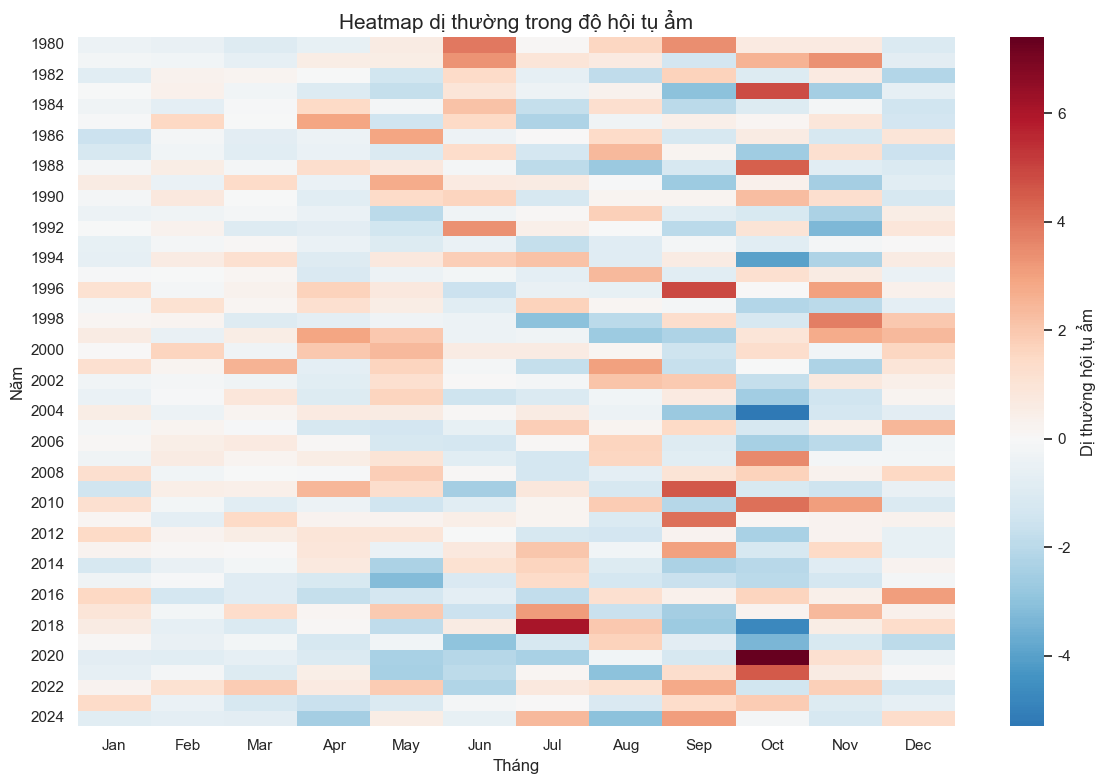

In [11]:
df_anom['time'] = pd.to_datetime(df_anom['time'])
df_anom['year'] = df_anom['time'].dt.year
df_anom['month'] = df_anom['time'].dt.month

# Aggregate daily anomalies to monthly means
monthly_anom = df_anom.groupby(['year', 'month'])['avg_vimdf'].mean().reset_index()

pivot_df = monthly_anom.pivot(index="year", columns="month", values="avg_vimdf")

# Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_df, 
    cmap='RdBu_r',
    center=0,
    annot=False,
    cbar_kws={'label': 'Dị thường hội tụ ẩm'}
)

plt.title('Heatmap dị thường trong độ hội tụ ẩm', fontsize=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Năm', fontsize=12)

plt.xticks(ticks=[i + 0.5 for i in range(12)], labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

## 2. Xu hướng lâu dài của độ hội tụ ẩm trung bình năm

Từ biểu đồ về độ hội tụ ẩm trung bình trong năm, ta thấy được rằng dù đường hồi quy tuyến tính có xu hướng giảm nhẹ, nhưng nhìn chung độ hội tụ ẩm trung bình qua các năm có sự biến động khá nhiều, dường như không tuân theo một quy luật cụ thể nào. Những năm gần đây giá trị hội tụ ẩm dường như có vẻ thấp hơn so với những năm trước.  

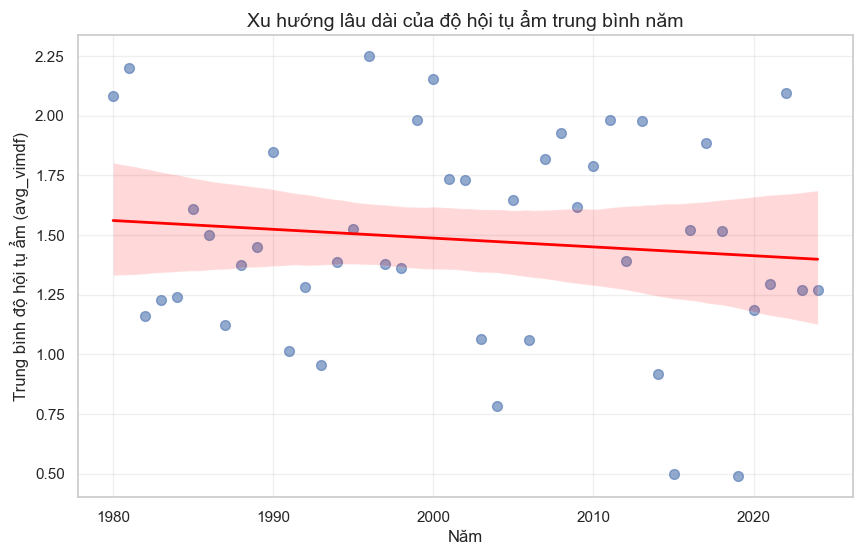

In [12]:
df_daily['time'] = pd.to_datetime(df_daily['time'])
df_daily['year'] = df_daily['time'].dt.year

annual_mc = df_daily.groupby('year')['avg_vimdf'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=annual_mc, x='year', y='avg_vimdf', 
            scatter_kws={'s': 50, 'alpha': 0.6}, 
            line_kws={'color': 'red', 'lw': 2})

plt.title('Xu hướng lâu dài của độ hội tụ ẩm trung bình năm', fontsize=14)
plt.ylabel('Trung bình độ hội tụ ẩm (avg_vimdf)')
plt.xlabel('Năm')
plt.grid(alpha=0.3)
plt.show()